# ECG EDA — Senior Design Dataset
Raw waveform exploration for the balanced preeclampsia vs. normal dataset.

- **369 recordings** (187 preeclampsia, 182 normal)
- **12 leads**: I, II, III, aVR, aVL, aVF, V1–V6
- **2500 samples @ 250 Hz = 10 seconds** per recording

## 0. Imports & constants

In [18]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Resolve project root by walking up from CWD until we find a known marker.
# Works whether the kernel CWD is the notebook directory or the project root.
def _find_project_root(markers=("requirements.txt", "src", ".git")):
    here = Path.cwd().resolve()
    for d in (here, *here.parents):
        if any((d / m).exists() for m in markers):
            return d
    raise RuntimeError(f"Project root not found above {here}")

PROJECT_ROOT = _find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.dataset import load_seniordesign, SD_LEAD_ORDER as LEAD_ORDER

DATA_DIR  = str(PROJECT_ROOT / "data" / "seniordesign_upload_balanced")
FS        = 250.0    # Hz
N_SAMPLES = 2500     # 10 seconds per recording

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_DIR:     {DATA_DIR}")

PROJECT_ROOT: /Users/ahmed/PycharmProjects/repnet
DATA_DIR:     /Users/ahmed/PycharmProjects/repnet/data/seniordesign_upload_balanced


## 1. Load metadata & verify file coverage

In [19]:
meta = pd.read_csv(os.path.join(DATA_DIR, "metadata_balanced.csv"))
print(f"Total records : {len(meta)}")
print(f"\nClass distribution:")
print(meta["PatLabel"].value_counts())
print(f"\nSample rate fields (first row): base={meta['REM_ECGSampleBase'].iloc[0]}, exp={meta['REM_ECGSampleExponent'].iloc[0]}")

Total records : 369

Class distribution:
PatLabel
Preeclampsia or Other Hypertensive Disorders of Pregnancy    187
Normal_All                                                   182
Name: count, dtype: int64

Sample rate fields (first row): base=500.0, exp=0.0


## 2. Dataloader

In [20]:
X, y = load_seniordesign(DATA_DIR)
t = np.arange(N_SAMPLES) / FS   # 0 to 5 seconds

print(f"X shape : {X.shape}   dtype: {X.dtype}")
print(f"Positives (preeclampsia): {y.sum()}  |  Negatives (normal): {(y==0).sum()}")
print(f"Duration: {N_SAMPLES/FS:.1f} s  |  FS: {FS} Hz")

X shape : (369, 12, 2500)   dtype: float32
Positives (preeclampsia): 187  |  Negatives (normal): 182
Duration: 10.0 s  |  FS: 250.0 Hz


## 3. Sanity check — single recording, all 12 leads

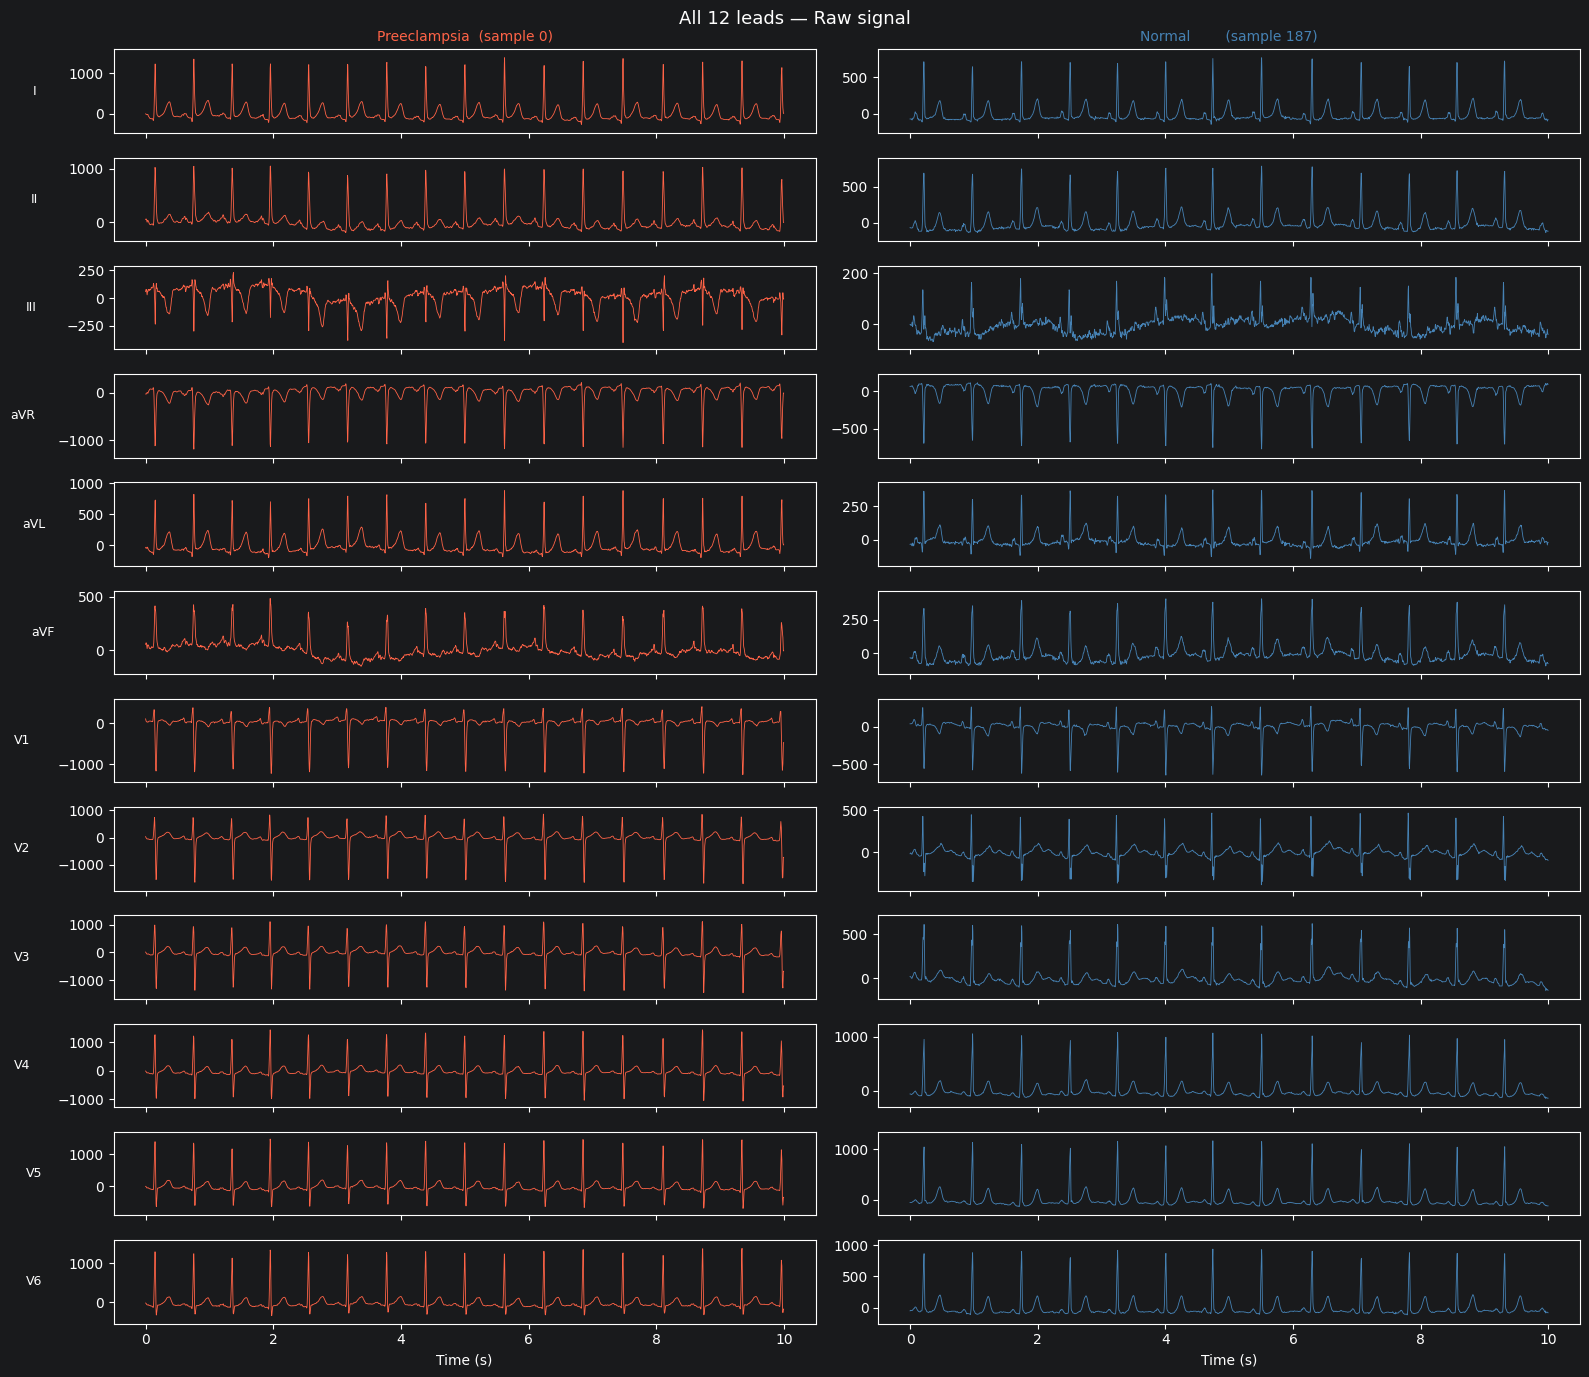

In [21]:
# Fixed samples used in every subsequent plot for consistency
VIS_POS = np.where(y == 1)[0][0]   # first preeclampsia
VIS_NEG = np.where(y == 0)[0][0]   # first normal
VIS_LEADS = LEAD_ORDER              # all 12

fig, axes = plt.subplots(12, 2, figsize=(16, 14), sharex=True, sharey=False)
fig.suptitle("All 12 leads — Raw signal", fontsize=13)
axes[0, 0].set_title(f"Preeclampsia  (sample {VIS_POS})", fontsize=10, color="tomato")
axes[0, 1].set_title(f"Normal        (sample {VIS_NEG})", fontsize=10, color="steelblue")

for i, lead in enumerate(VIS_LEADS):
    for col, (idx, color) in enumerate([(VIS_POS, "tomato"), (VIS_NEG, "steelblue")]):
        sig = X[idx, i]
        ax = axes[i, col]
        ax.plot(t, sig, lw=0.6, color=color)
        pad = max(abs(sig.max()), abs(sig.min())) * 0.15 or 1
        ax.set_ylim(sig.min() - pad, sig.max() + pad)
        if col == 0:
            ax.set_ylabel(lead, fontsize=9, rotation=0, labelpad=25, va="center")

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## 4. Progressive pipeline stages

In [22]:
from src.preprocessing.filters import BaselineWanderFilter
from src.preprocessing.normalization import ZScoreNormalization
from src.preprocessing.base import PreprocessingPipeline

# BWF params: cutoff=0.67 Hz (vs default 0.5), order=6 (vs default 4)
# Higher cutoff -> more low-freq drift removed; higher order -> steeper rolloff
BWF_CUTOFF = 0.5    # Hz
BWF_ORDER  = 4

# Stage snapshots — keep X_raw unmodified
X_raw = X.copy()

X_bwf = X_raw.copy()
X_bwf, _ = BaselineWanderFilter(cutoff=BWF_CUTOFF, order=BWF_ORDER, fs=FS).transform(X_bwf)

X_norm = X_bwf.copy()
X_norm, _ = ZScoreNormalization(per_lead=True).transform(X_norm)

print(f"BWF: cutoff={BWF_CUTOFF} Hz, order={BWF_ORDER}")
print("Stage shapes (all must match):")
print(f"  raw  : {X_raw.shape}")
print(f"  +BWF : {X_bwf.shape}")
print(f"  +norm: {X_norm.shape}")
print("\nZ-score check on X_norm - mean~0, std~1 per lead (first sample, first 3 leads):")
print(f"  mean: {X_norm[0].mean(axis=1)[:3].round(3)}")
print(f"  std : {X_norm[0].std(axis=1)[:3].round(3)}")

BWF: cutoff=0.5 Hz, order=4
Stage shapes (all must match):
  raw  : (369, 12, 2500)
  +BWF : (369, 12, 2500)
  +norm: (369, 12, 2500)

Z-score check on X_norm - mean~0, std~1 per lead (first sample, first 3 leads):
  mean: [ 0. -0. -0.]
  std : [1. 1. 1.]


## 5. Pipeline stages — All 12 leads comparison

| Stage | What happens |
|---|---|
| **Raw** | ADC counts straight off disk — may have slow drift and varying amplitude scale |
| **+ Baseline Wander Filter** | 4th-order zero-phase high-pass Butterworth at 0.5 Hz removes respiratory/motion drift below 0.5 Hz |
| **+ Z-score Norm** | Each lead independently shifted to mean=0, std=1 — removes inter-lead amplitude differences |

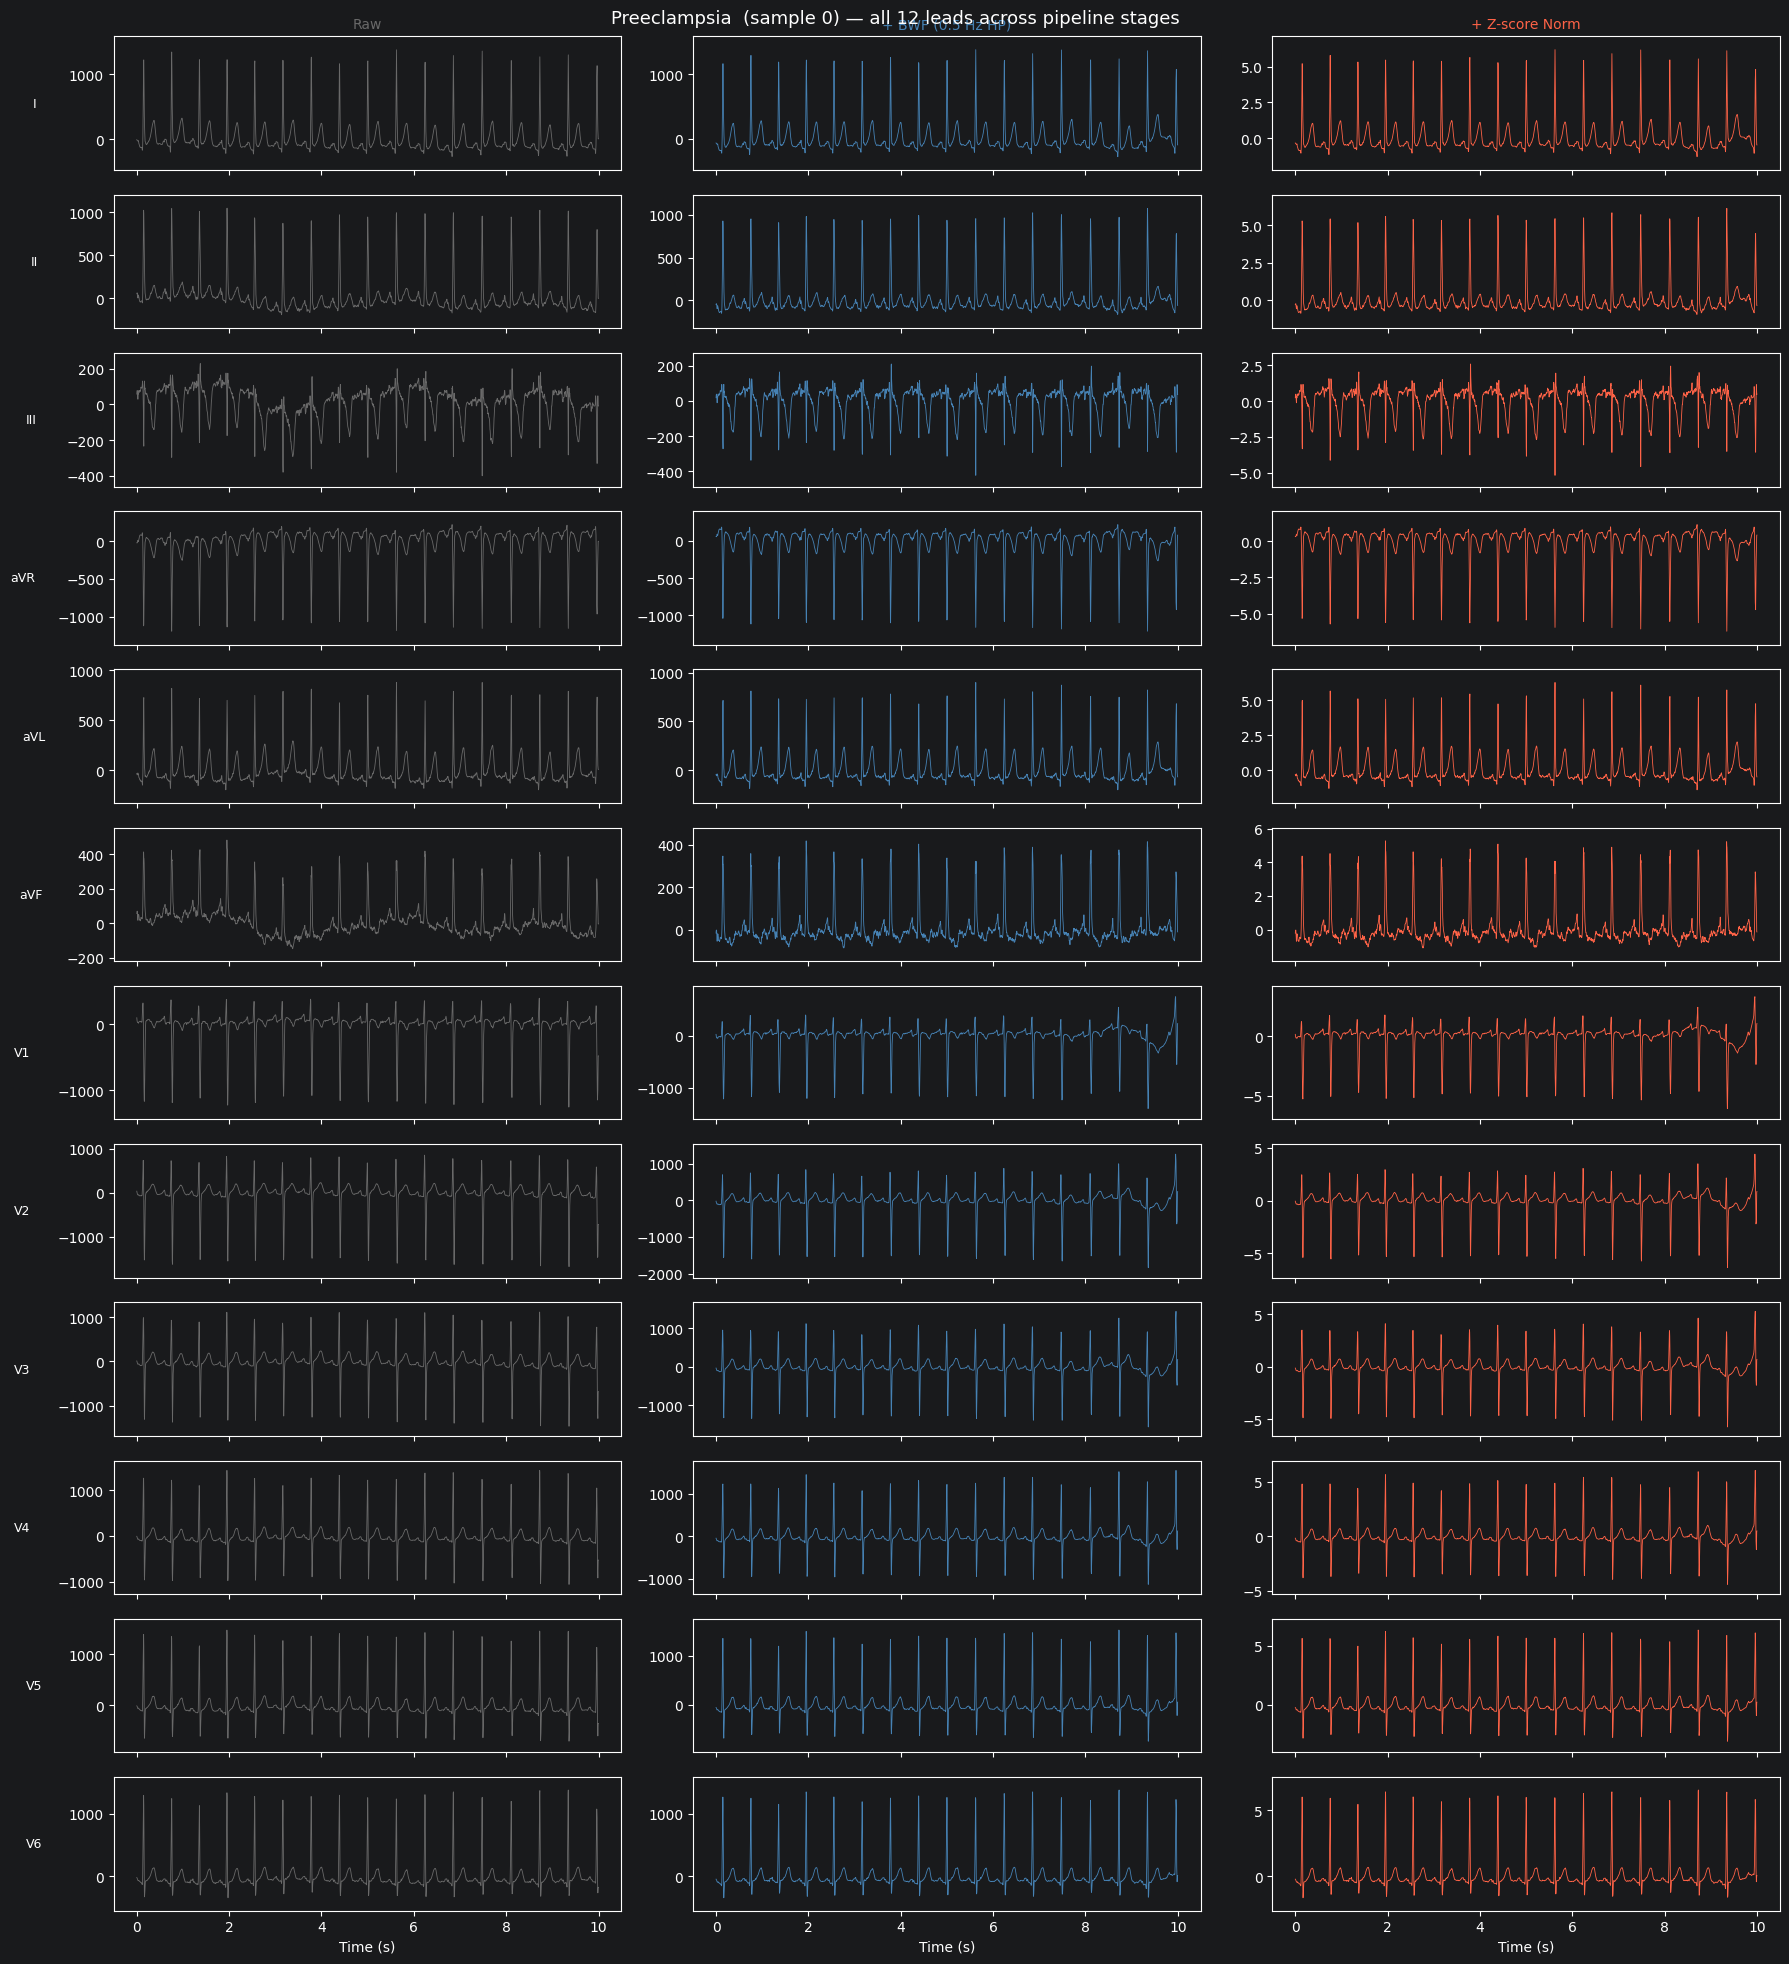

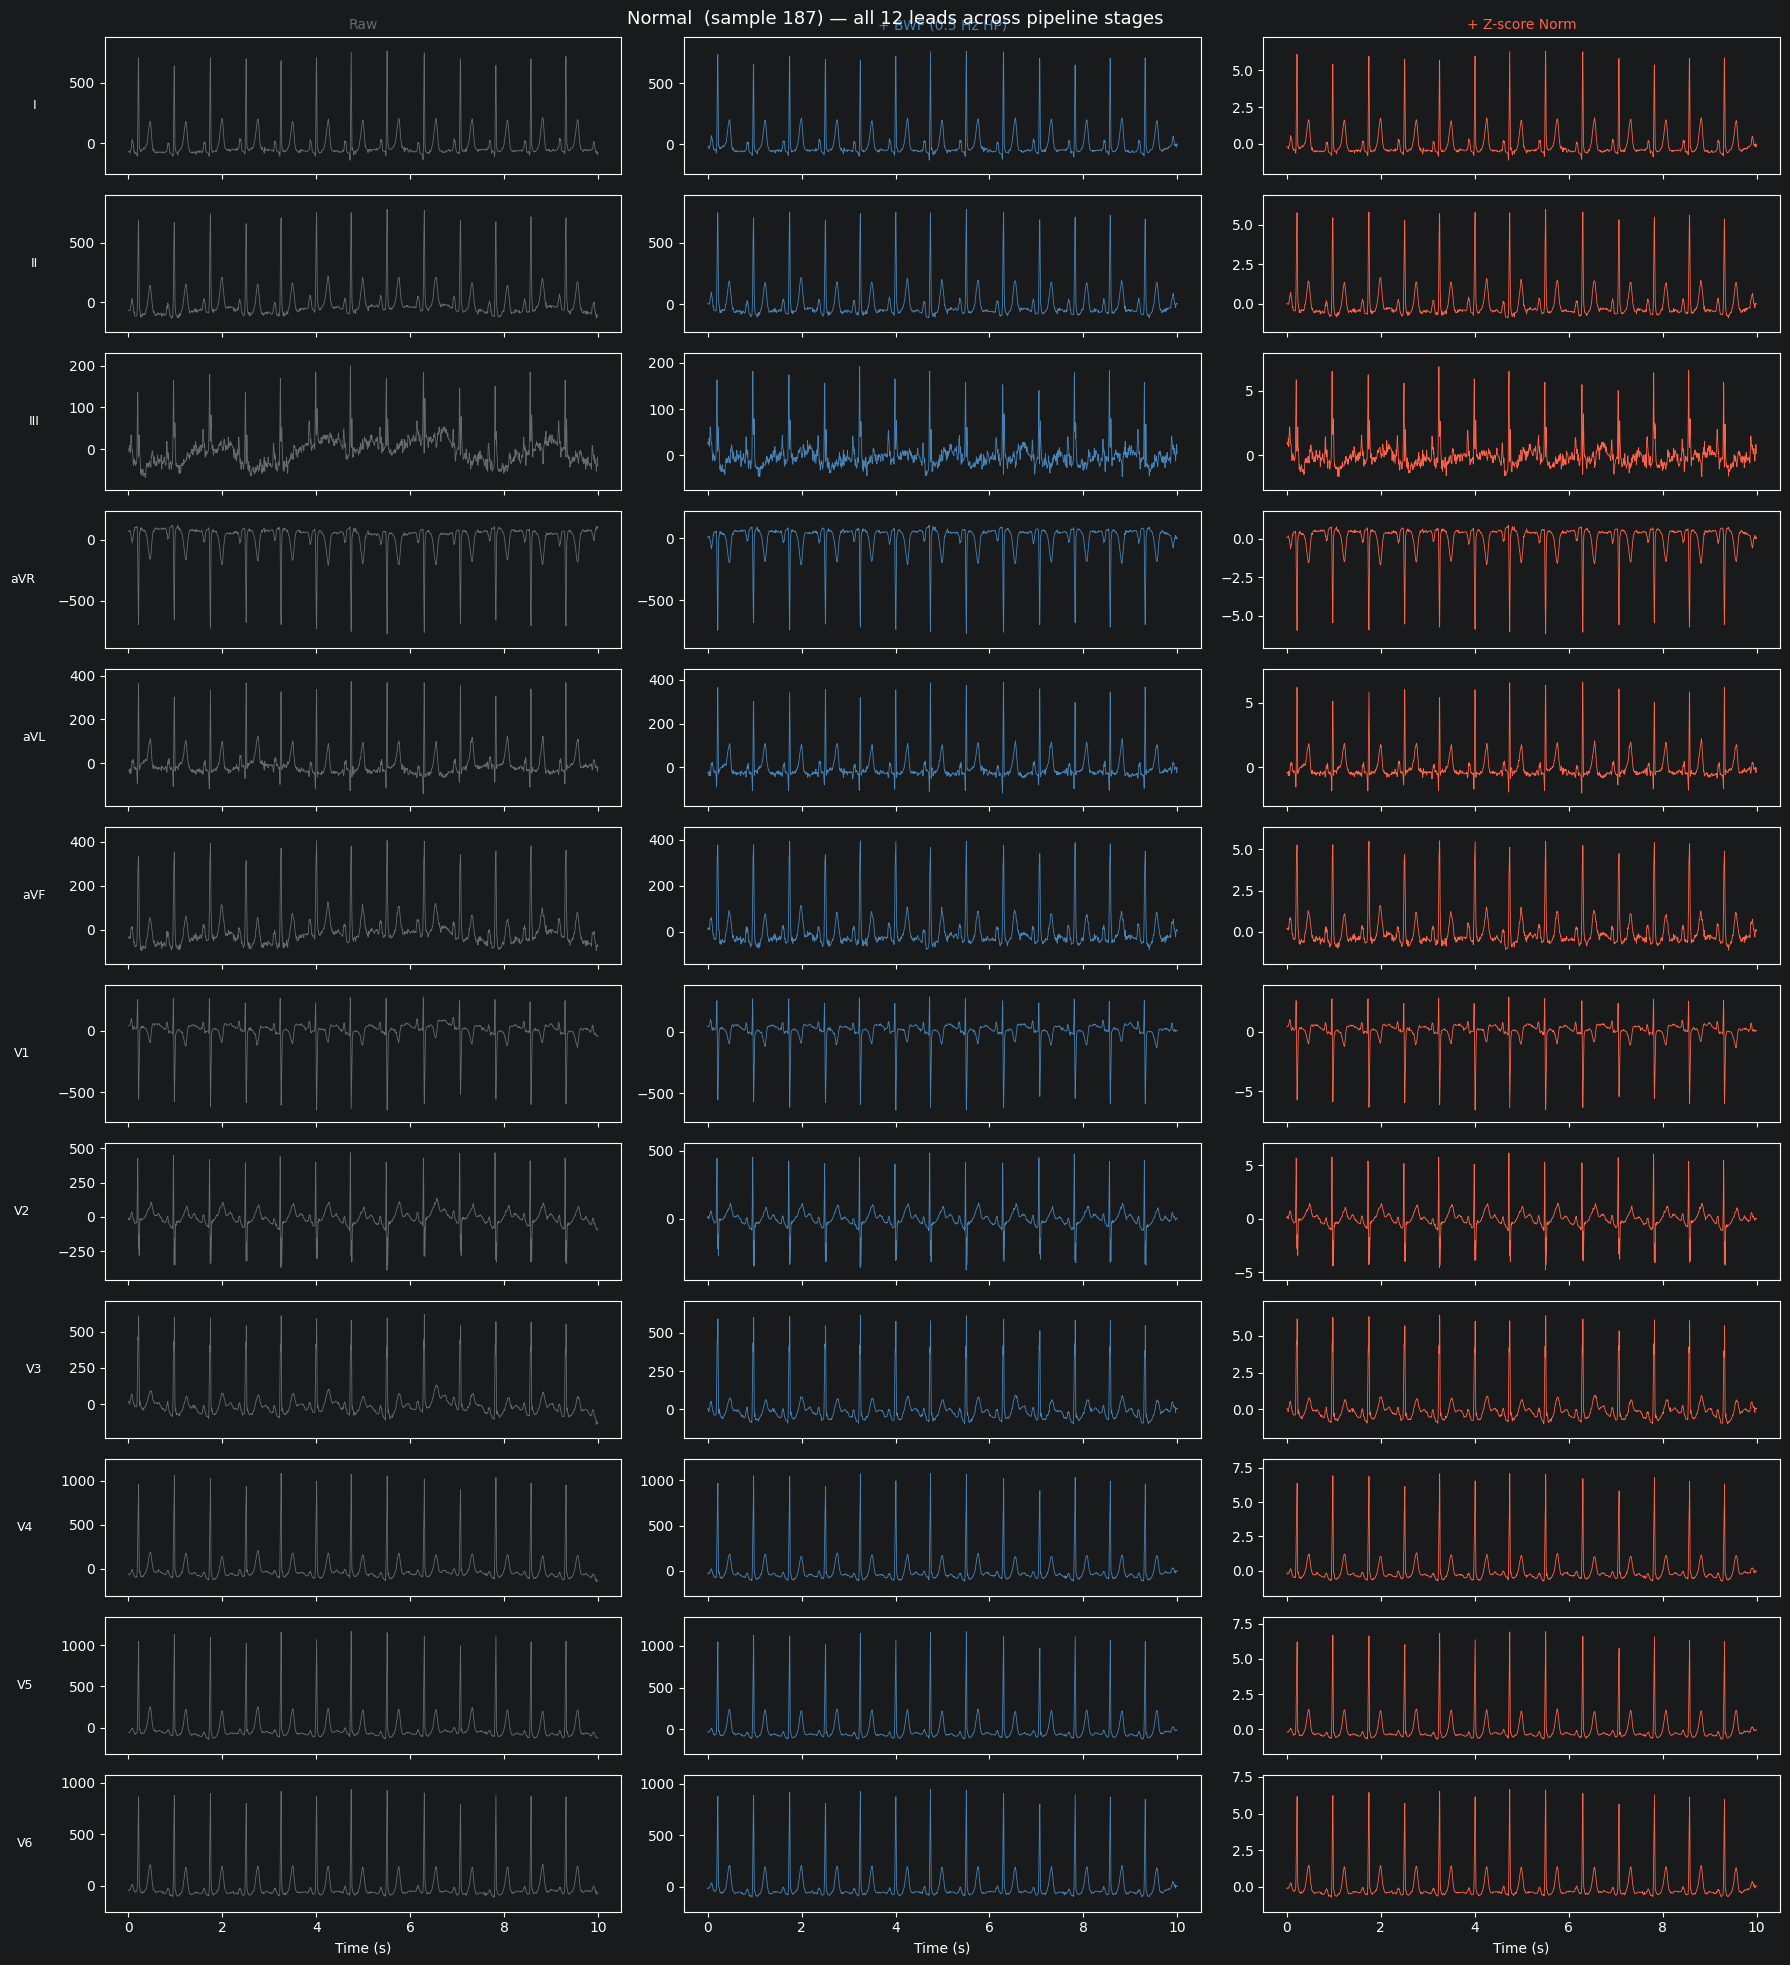

In [23]:
LEAD_VIS = "II"
li = LEAD_ORDER.index(LEAD_VIS)
stages = [
    ("Raw", X_raw,  "dimgray"),
    ("+ BWF (0.5 Hz HP)", X_bwf,  "steelblue"),
    ("+ Z-score Norm", X_norm, "tomato"),
]
show = [("Preeclampsia", VIS_POS), ("Normal", VIS_NEG)]

for class_lbl, idx in show:
    fig, axes = plt.subplots(12, 3, figsize=(18, 20), sharex=True)
    fig.suptitle(f"{class_lbl}  (sample {idx}) — all 12 leads across pipeline stages", fontsize=13)

    for col, (stage_name, X_stage, color) in enumerate(stages):
        axes[0, col].set_title(stage_name, fontsize=10, color=color)
        for row, lead in enumerate(LEAD_ORDER):
            sig = X_stage[idx, row]
            ax = axes[row, col]
            ax.plot(t, sig, lw=0.6, color=color)
            pad = max(abs(sig.max()), abs(sig.min())) * 0.15 or 0.1
            ax.set_ylim(sig.min() - pad, sig.max() + pad)
            if col == 0:
                ax.set_ylabel(lead, fontsize=9, rotation=0, labelpad=25, va="center")
            if row == 11:
                ax.set_xlabel("Time (s)")

    plt.tight_layout()
    plt.show()

## 6. All 12 leads — post-pipeline

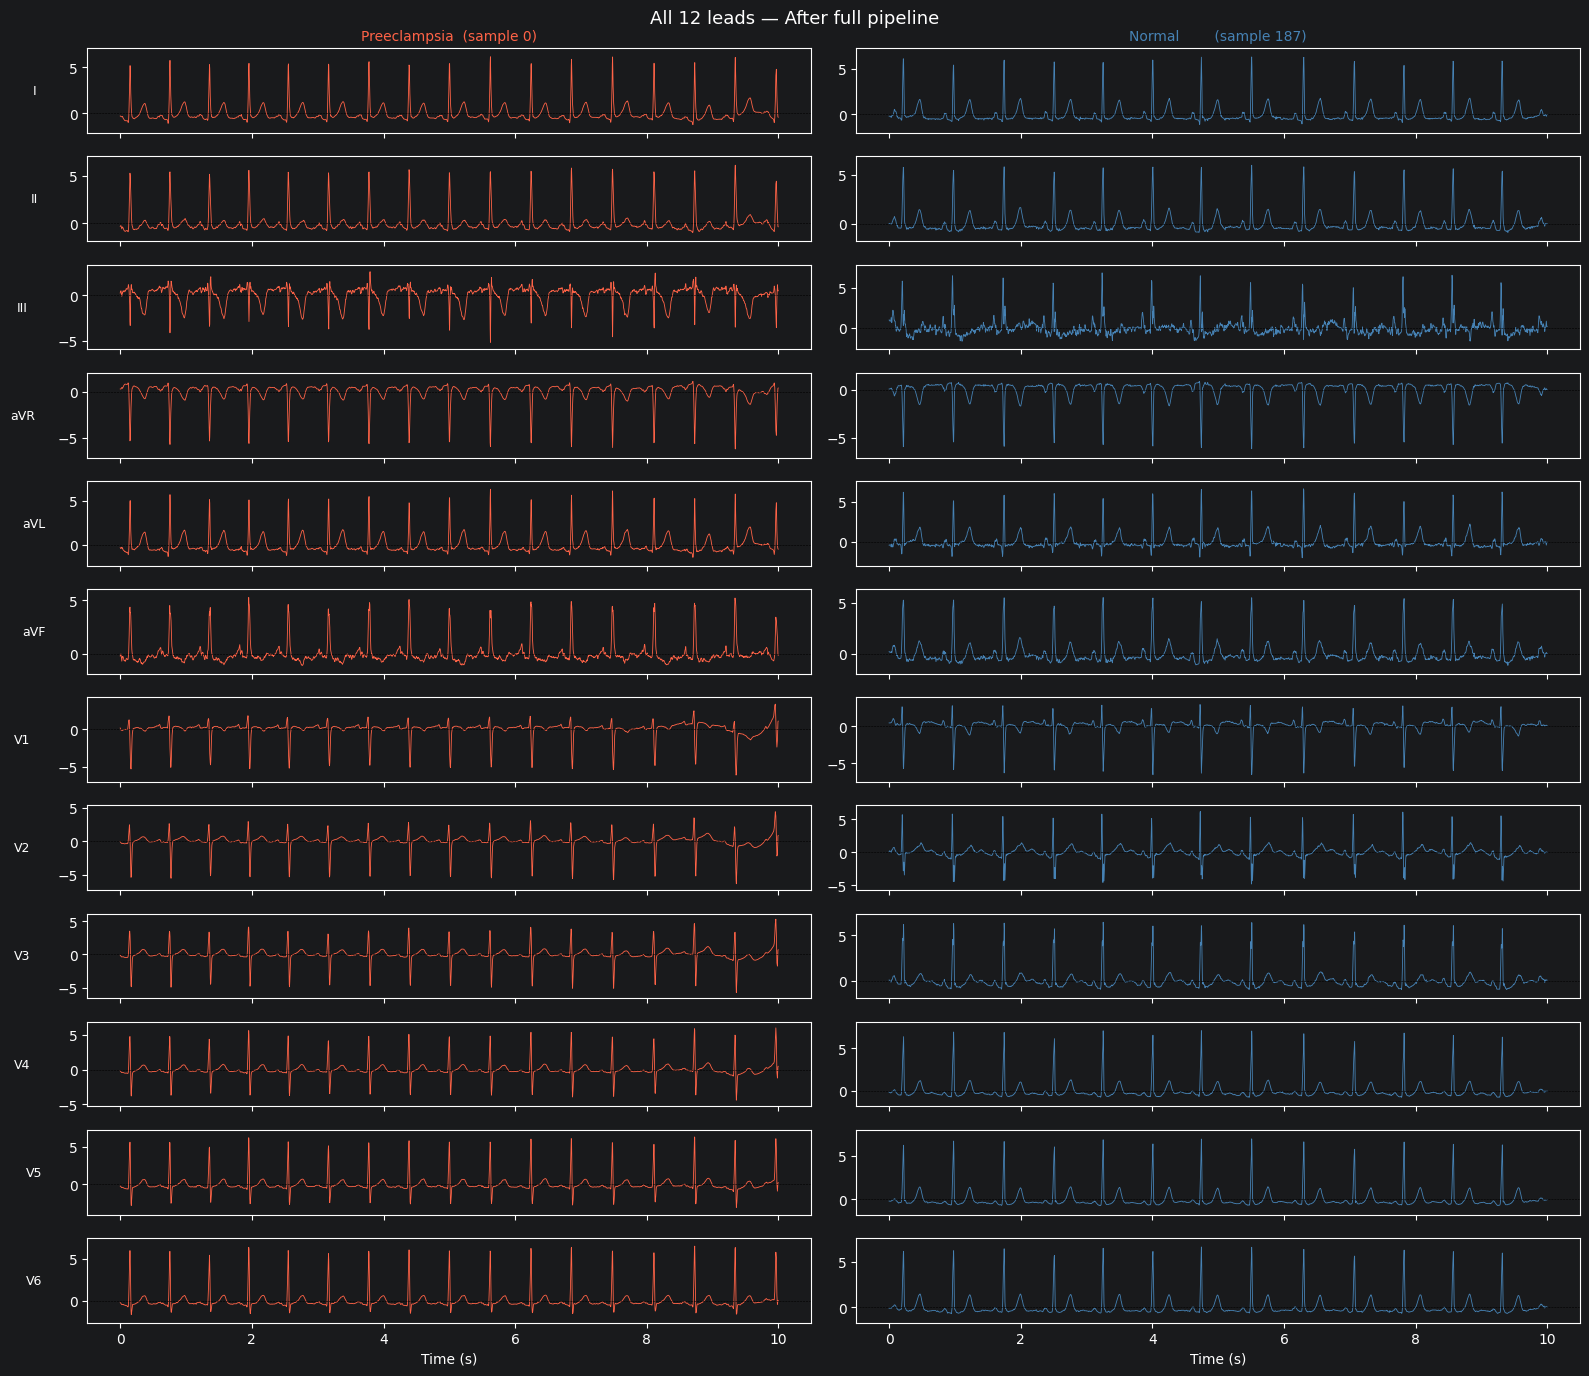

In [24]:
fig, axes = plt.subplots(12, 2, figsize=(16, 14), sharex=True, sharey=False)
fig.suptitle("All 12 leads — After full pipeline", fontsize=13)
axes[0, 0].set_title(f"Preeclampsia  (sample {VIS_POS})", fontsize=10, color="tomato")
axes[0, 1].set_title(f"Normal        (sample {VIS_NEG})", fontsize=10, color="steelblue")

for i, lead in enumerate(LEAD_ORDER):
    for col, (idx, color) in enumerate([(VIS_POS, "tomato"), (VIS_NEG, "steelblue")]):
        sig = X_norm[idx, i]
        ax = axes[i, col]
        ax.plot(t, sig, lw=0.6, color=color)
        ax.axhline(0, lw=0.4, color="k", linestyle="--")
        pad = max(abs(sig.max()), abs(sig.min())) * 0.15 or 0.1
        ax.set_ylim(sig.min() - pad, sig.max() + pad)
        if col == 0:
            ax.set_ylabel(lead, fontsize=9, rotation=0, labelpad=25, va="center")

axes[-1, 0].set_xlabel("Time (s)")
axes[-1, 1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## 7. Mean ± std waveform per lead, per class

Average waveform shape across all samples in each class, with ±1 std shading.
**What to look for:** Where do the colored bands diverge? That time region (P-wave ~0–0.2 s, QRS ~0.2–0.3 s, ST/T ~0.3–0.6 s) tells you what temporal scale your CNN kernels need to cover.

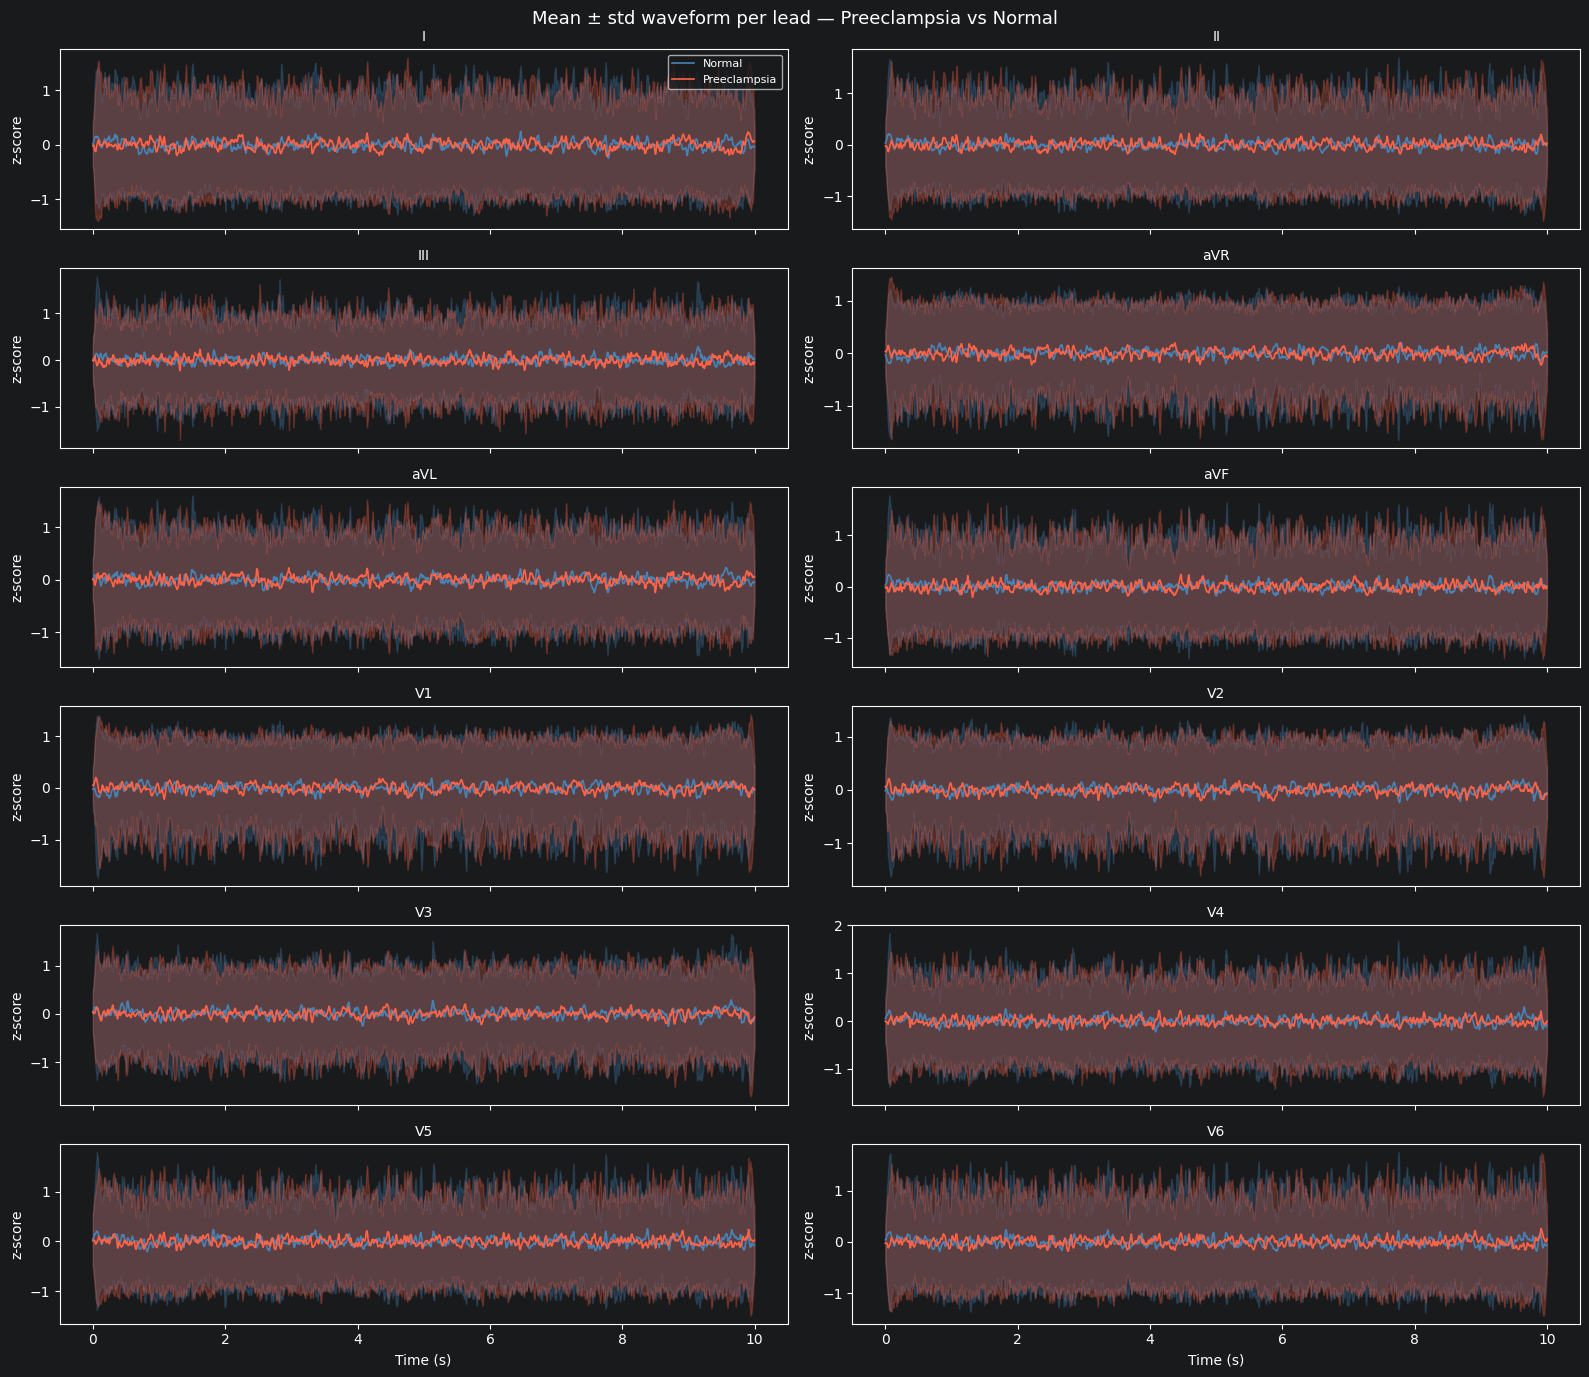

In [25]:
X_pos = X_norm[y == 1]   # (N_pos, 12, 2500)
X_neg = X_norm[y == 0]   # (N_neg, 12, 2500)

mean_pos = X_pos.mean(axis=0)  # (12, 2500)
std_pos  = X_pos.std(axis=0)
mean_neg = X_neg.mean(axis=0)
std_neg  = X_neg.std(axis=0)

fig, axes = plt.subplots(6, 2, figsize=(16, 14), sharex=True)
fig.suptitle("Mean ± std waveform per lead — Preeclampsia vs Normal", fontsize=13)

for i, (ax, lead) in enumerate(zip(axes.flat, LEAD_ORDER)):
    ax.fill_between(t, mean_neg[i]-std_neg[i], mean_neg[i]+std_neg[i],
                    alpha=0.25, color="steelblue")
    ax.plot(t, mean_neg[i], color="steelblue", lw=1.2, label="Normal")
    ax.fill_between(t, mean_pos[i]-std_pos[i], mean_pos[i]+std_pos[i],
                    alpha=0.25, color="tomato")
    ax.plot(t, mean_pos[i], color="tomato", lw=1.2, label="Preeclampsia")
    ax.set_title(lead, fontsize=10)
    ax.set_ylabel("z-score")

axes[0, 0].legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

## 8. Power spectral density per lead, per class

Average PSD (Welch method) across all samples in each class.
**What to look for:** If the class difference is concentrated below 40 Hz, the CNN can use larger kernels (~50–100 samples). A difference at higher frequencies means finer kernels (~10–25 samples) are needed.

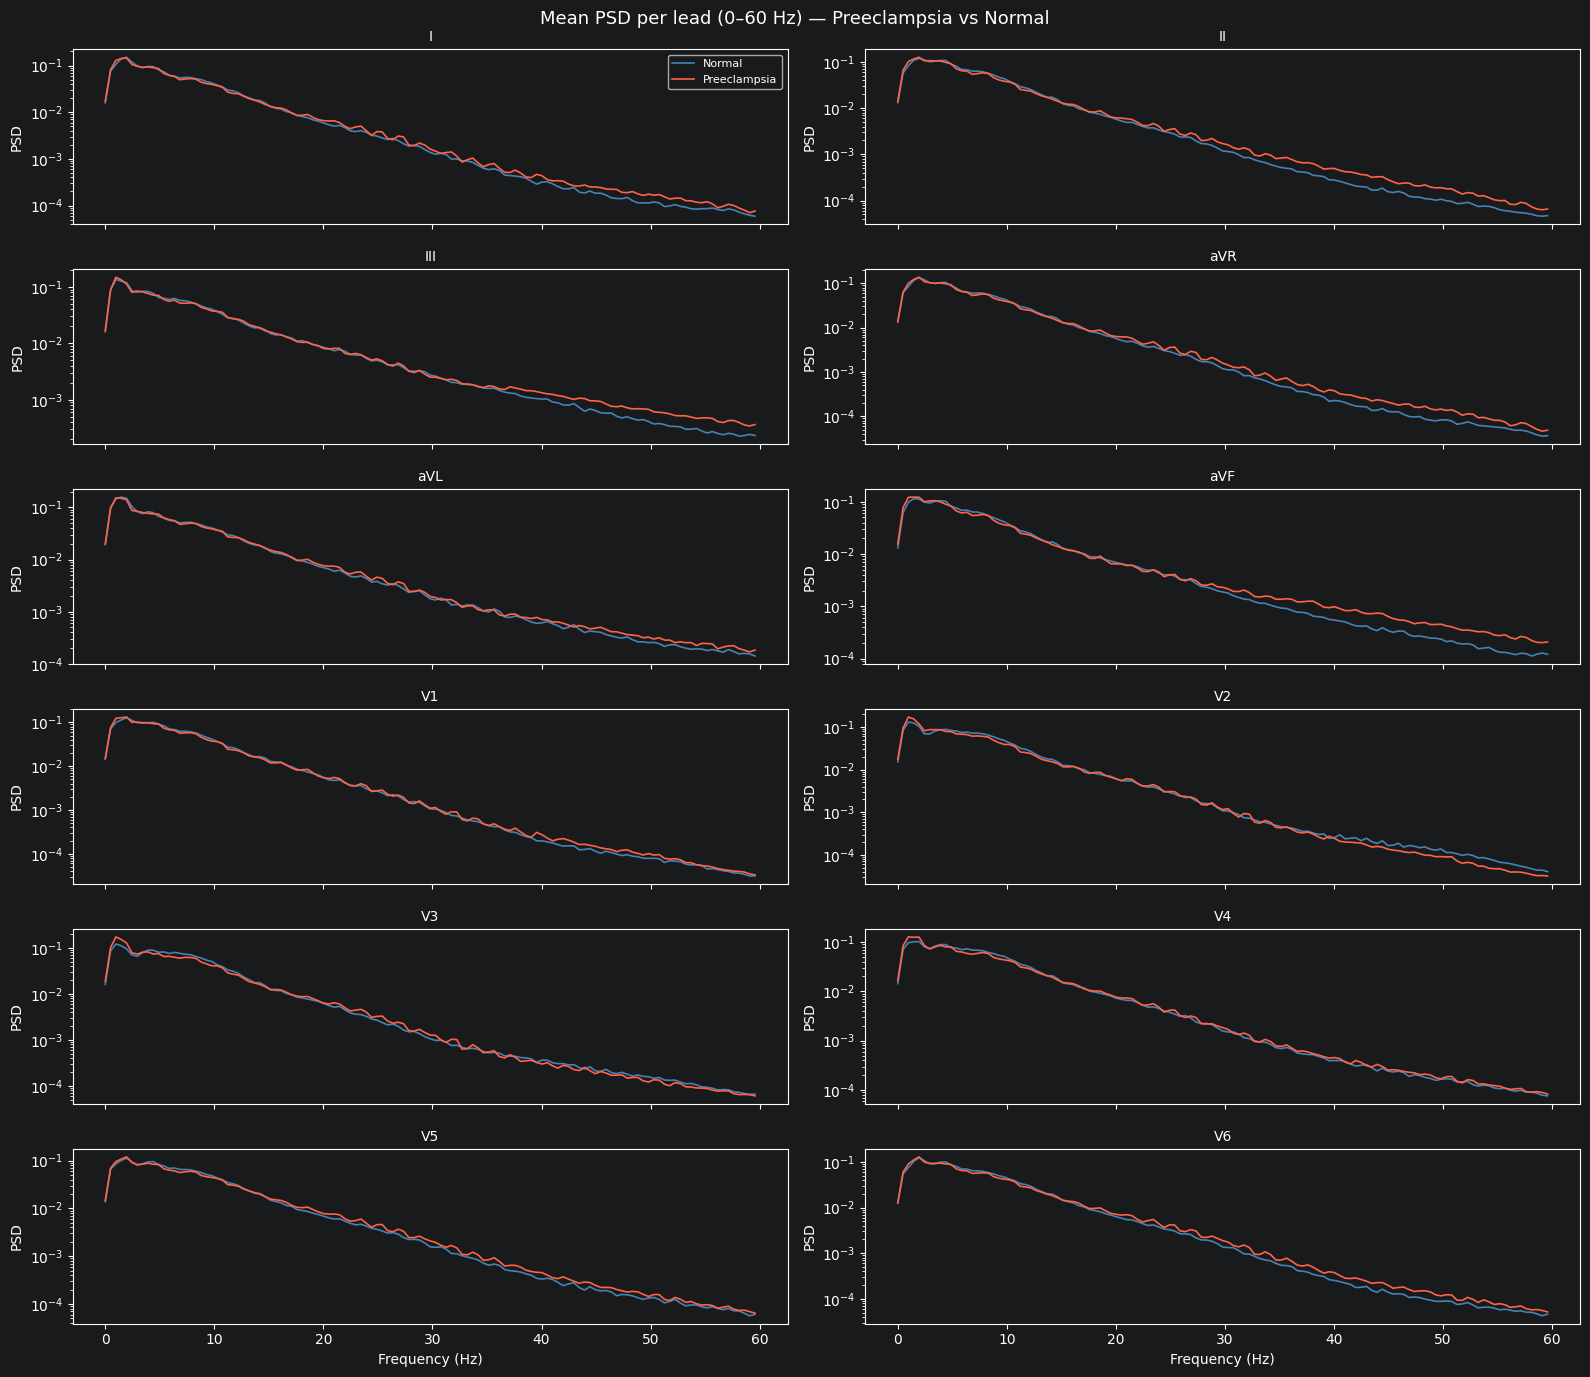

In [26]:
from scipy.signal import welch

def class_psd(X_class, lead_i, fs=FS, nperseg=512):
    psds = [welch(sig, fs=fs, nperseg=nperseg)[1] for sig in X_class[:, lead_i, :]]
    f = welch(X_class[0, lead_i], fs=fs, nperseg=nperseg)[0]
    return f, np.stack(psds).mean(axis=0)

fig, axes = plt.subplots(6, 2, figsize=(16, 14), sharex=True)
fig.suptitle("Mean PSD per lead (0–60 Hz) — Preeclampsia vs Normal", fontsize=13)

for i, (ax, lead) in enumerate(zip(axes.flat, LEAD_ORDER)):
    f, psd_neg = class_psd(X_neg, i)
    f, psd_pos = class_psd(X_pos, i)
    mask = f <= 60
    ax.semilogy(f[mask], psd_neg[mask], color="steelblue", lw=1.2, label="Normal")
    ax.semilogy(f[mask], psd_pos[mask], color="tomato",    lw=1.2, label="Preeclampsia")
    ax.set_title(lead, fontsize=10)
    ax.set_ylabel("PSD")

axes[0, 0].legend(fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.show()

## 9. Lead discriminability

Two-sample t-test on per-sample, per-lead RMS amplitude. Higher −log10(p) = more discriminative.
**What to look for:** If a few leads dominate, a lead-attention gate in the CNN helps. If all 12 contribute roughly equally, use a shared backbone.

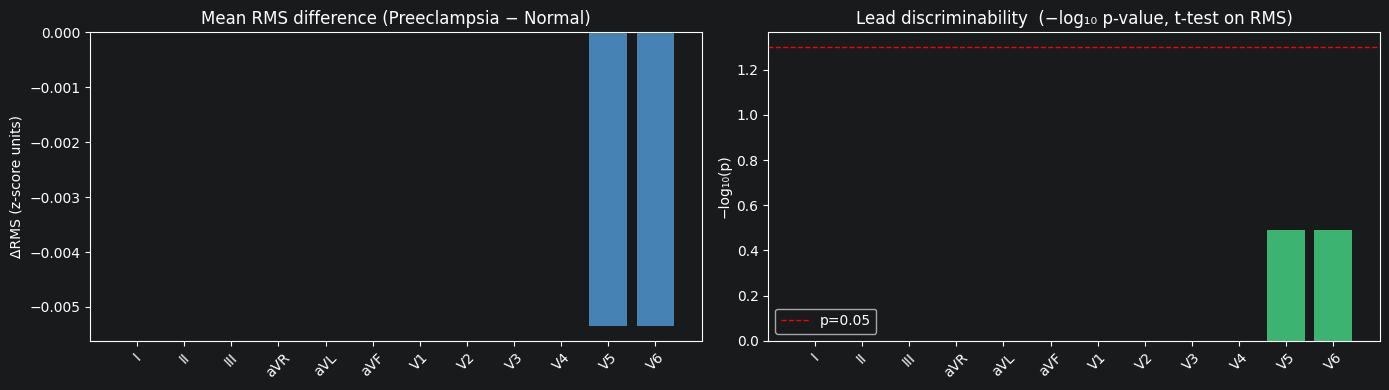

Leads ranked by discriminability:
  V6     p=0.3245  ΔRMS=-0.0053
  V5     p=0.3245  ΔRMS=-0.0053
  I      p=1.0000  ΔRMS=+0.0000
  II     p=1.0000  ΔRMS=+0.0000
  III    p=1.0000  ΔRMS=+0.0000
  aVR    p=1.0000  ΔRMS=+0.0000
  aVL    p=1.0000  ΔRMS=+0.0000
  aVF    p=1.0000  ΔRMS=+0.0000
  V1     p=1.0000  ΔRMS=+0.0000
  V2     p=1.0000  ΔRMS=+0.0000
  V3     p=1.0000  ΔRMS=+0.0000
  V4     p=1.0000  ΔRMS=+0.0000


In [27]:
import warnings
from scipy.stats import ttest_ind

rms_pos = np.sqrt((X_pos ** 2).mean(axis=2))  # (N_pos, 12)
rms_neg = np.sqrt((X_neg ** 2).mean(axis=2))  # (N_neg, 12)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    _, p_vals = ttest_ind(rms_pos, rms_neg, axis=0)

neg_log_p = -np.log10(np.clip(p_vals, 1e-10, 1))
amp_diff  = rms_pos.mean(axis=0) - rms_neg.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(LEAD_ORDER, amp_diff,
            color=["tomato" if d > 0 else "steelblue" for d in amp_diff])
axes[0].axhline(0, color="k", lw=0.8)
axes[0].set_title("Mean RMS difference (Preeclampsia − Normal)")
axes[0].set_ylabel("ΔRMS (z-score units)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(LEAD_ORDER, neg_log_p, color="mediumseagreen")
axes[1].axhline(-np.log10(0.05), color="red", lw=1, linestyle="--", label="p=0.05")
axes[1].set_title("Lead discriminability  (−log₁₀ p-value, t-test on RMS)")
axes[1].set_ylabel("−log₁₀(p)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

order = np.argsort(p_vals)
print("Leads ranked by discriminability:")
for i in order:
    print(f"  {LEAD_ORDER[i]:5s}  p={p_vals[i]:.4f}  ΔRMS={amp_diff[i]:+.4f}")

## 10. Temporal localization

Sliding-window mean absolute difference between class mean waveforms, averaged over all 12 leads.
**What to look for:** Peaks tell you *when* in the 10 s strip the classes differ most. A narrow peak → short context window / local CNN features suffice. A broad or multi-peak pattern → the Transformer needs full-sequence attention.

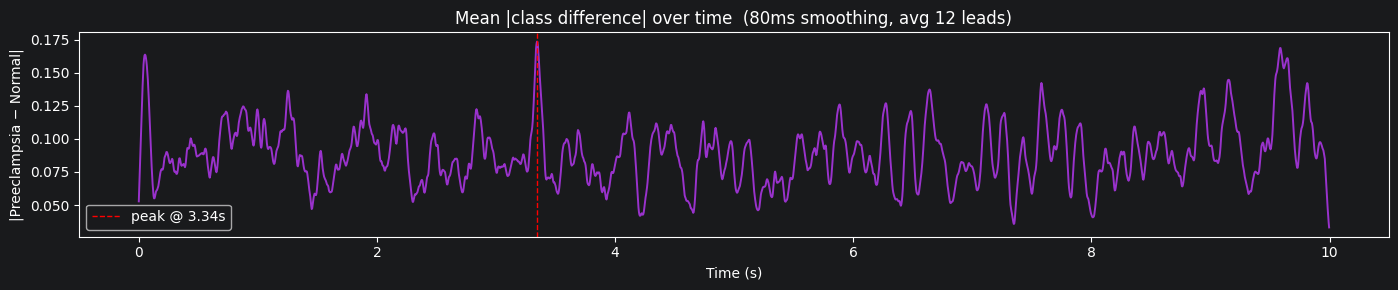

Peak difference at t=3.344s


In [28]:
WINDOW_MS = 80   # smoothing window in ms
W = int(WINDOW_MS / 1000 * FS)

diff_t = np.abs(mean_pos - mean_neg).mean(axis=0)  # (2500,) averaged over leads
kernel = np.ones(W) / W
diff_smooth = np.convolve(diff_t, kernel, mode="same")

peak_t = t[np.argmax(diff_smooth)]

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(t, diff_smooth, color="darkorchid", lw=1.4)
ax.axvline(peak_t, color="red", lw=1, linestyle="--", label=f"peak @ {peak_t:.2f}s")
ax.set_title(f"Mean |class difference| over time  ({WINDOW_MS}ms smoothing, avg 12 leads)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("|Preeclampsia − Normal|")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Peak difference at t={peak_t:.3f}s")

## 11. Inter-lead correlation

Average lead-lead correlation matrix within each class, plus the difference.
**What to look for:** If the difference matrix has large off-diagonal values, preeclampsia disrupts normal lead coupling — a 2D conv across leads (treating the 12×T signal as an image) would capture this. If the matrices look similar, independent per-lead 1D CNNs are sufficient.

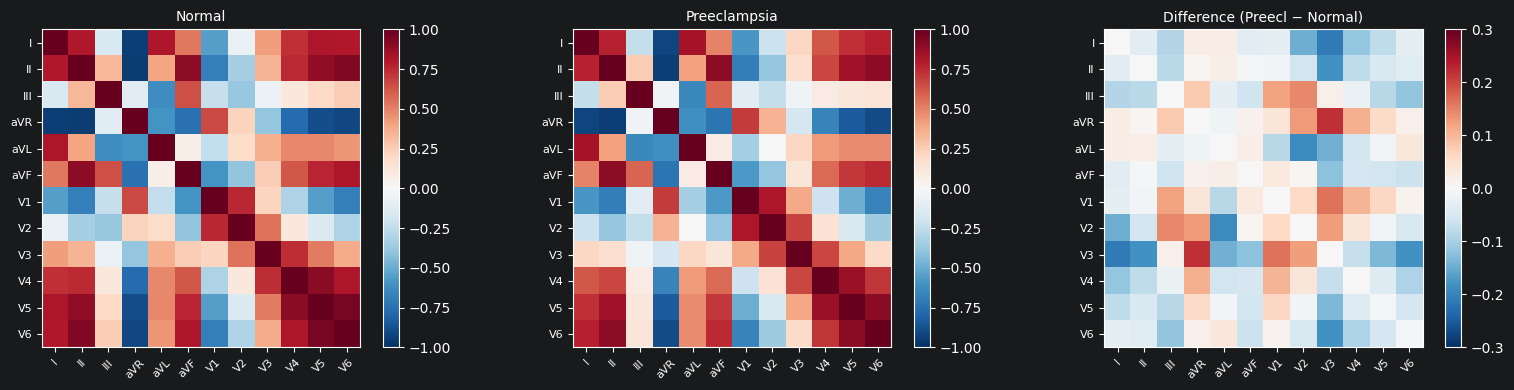

In [29]:
def mean_corr(X_class):
    corrs = []
    for x in X_class:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            c = np.corrcoef(x)
        np.nan_to_num(c, copy=False, nan=0.0)
        corrs.append(c)
    return np.stack(corrs).mean(axis=0)  # (12, 12)

corr_pos = mean_corr(X_pos)
corr_neg = mean_corr(X_neg)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, mat, title, vmax in zip(
    axes,
    [corr_neg, corr_pos, corr_pos - corr_neg],
    ["Normal", "Preeclampsia", "Difference (Preecl − Normal)"],
    [1.0, 1.0, 0.3],
):
    im = ax.imshow(mat, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(12)); ax.set_xticklabels(LEAD_ORDER, rotation=45, fontsize=8)
    ax.set_yticks(range(12)); ax.set_yticklabels(LEAD_ORDER, fontsize=8)
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

## 12. Amplitude outlier check

Per-lead RMS distribution across all 369 recordings (box + strip plot).
**What to look for:** Outlier recordings with extreme RMS will destabilize training. If you see values >5× the median, add a hard clip (e.g. ±5σ) to the preprocessing pipeline.

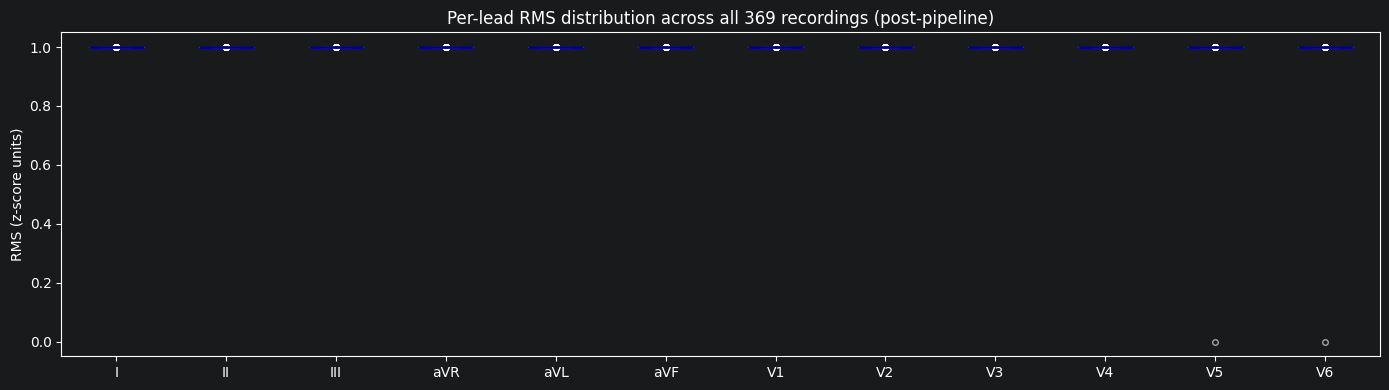

Leads with outliers (RMS > 3.5):


In [30]:
rms_all = np.sqrt((X_norm ** 2).mean(axis=2))  # (369, 12)

fig, ax = plt.subplots(figsize=(14, 4))
ax.boxplot([rms_all[:, i] for i in range(12)],
           tick_labels=LEAD_ORDER, patch_artist=True,
           boxprops=dict(facecolor="lightsteelblue", alpha=0.7),
           medianprops=dict(color="navy", lw=2),
           flierprops=dict(marker="o", color="tomato", markersize=4, alpha=0.6))
ax.set_title("Per-lead RMS distribution across all 369 recordings (post-pipeline)")
ax.set_ylabel("RMS (z-score units)")
plt.tight_layout()
plt.show()

print("Leads with outliers (RMS > 3.5):")
for i, lead in enumerate(LEAD_ORDER):
    outliers = np.where(rms_all[:, i] > 3.5)[0]
    if len(outliers):
        print(f"  {lead}: {len(outliers)} recording(s), max RMS={rms_all[outliers, i].max():.2f}")

## 12b. Normalization strategy — per-lead distribution shape

Kurtosis and skewness of the per-lead amplitude distribution across all 369 recordings (computed on **filtered but unnormalized** data to evaluate whether z-score is the right normalization choice).

| Distribution shape | Best normalization |
|---|---|
| Symmetric, light tails (kurtosis ~3, \|skew\| < 1) | Z-score (mean/std) |
| Heavy tails (kurtosis >> 3) | Robust (median/IQR) |
| Skewed (\|skew\| > 1) | Robust or log-transform first |

## 13. Class separability — UMAP

UMAP on 36 hand-crafted features (mean, std, skew per lead) applied to the post-pipeline data.
**What to look for:** Clear separation → a shallow model may suffice. Heavy overlap → the Transformer's long-range attention is genuinely needed to find subtle discriminative patterns.

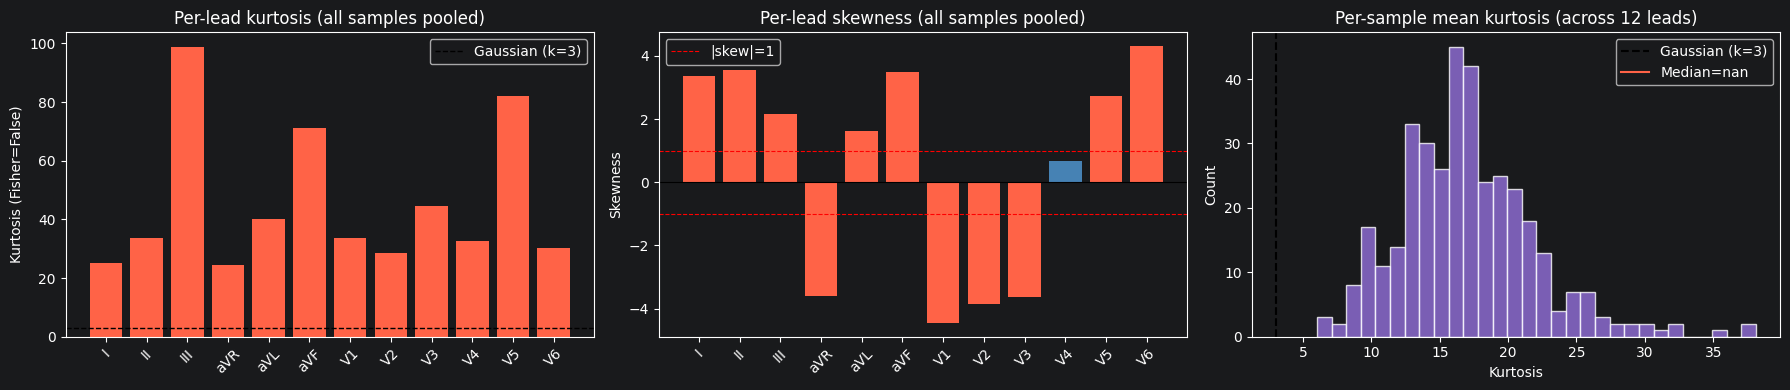

Mean kurtosis across leads: 45.45  (Gaussian=3.0)
Mean |skewness| across leads: 3.116
Leads with kurtosis > 5 (heavy tails): 12/12
Leads with |skewness| > 1 (asymmetric): 11/12

Recommendation: Robust normalization (median/IQR) — heavy-tailed distributions


In [31]:
from scipy.stats import kurtosis as scipy_kurtosis, skew as scipy_skew

# Compute per-lead kurtosis and skewness on FILTERED but UNNORMALIZED data (X_bwf)
# This tells us whether the raw amplitude distributions are suitable for z-score
# or whether robust normalization (median/IQR) would be more appropriate.

# Flatten all timepoints across all samples per lead: (369*2500,) per lead
kurt_per_lead = np.array([scipy_kurtosis(X_bwf[:, i, :].ravel(), fisher=False)
                          for i in range(12)])
skew_per_lead = np.array([scipy_skew(X_bwf[:, i, :].ravel())
                          for i in range(12)])

# Also compute per-SAMPLE kurtosis (mean across leads) to find heavy-tailed recordings
kurt_per_sample = np.array([
    np.mean([scipy_kurtosis(X_bwf[n, l, :], fisher=False) for l in range(12)])
    for n in range(X_bwf.shape[0])
])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Per-lead kurtosis
colors_k = ["tomato" if k > 5 else "steelblue" for k in kurt_per_lead]
axes[0].bar(LEAD_ORDER, kurt_per_lead, color=colors_k)
axes[0].axhline(3.0, color="k", lw=1, linestyle="--", label="Gaussian (k=3)")
axes[0].set_title("Per-lead kurtosis (all samples pooled)")
axes[0].set_ylabel("Kurtosis (Fisher=False)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

# Per-lead skewness
colors_s = ["tomato" if abs(s) > 1 else "steelblue" for s in skew_per_lead]
axes[1].bar(LEAD_ORDER, skew_per_lead, color=colors_s)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].axhline(1.0, color="red", lw=0.8, linestyle="--", label="|skew|=1")
axes[1].axhline(-1.0, color="red", lw=0.8, linestyle="--")
axes[1].set_title("Per-lead skewness (all samples pooled)")
axes[1].set_ylabel("Skewness")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

# Per-sample kurtosis distribution
axes[2].hist(kurt_per_sample, bins=30, color="mediumpurple", edgecolor="white", alpha=0.8)
axes[2].axvline(3.0, color="k", lw=1.5, linestyle="--", label="Gaussian (k=3)")
axes[2].axvline(np.median(kurt_per_sample), color="tomato", lw=1.5, linestyle="-",
                label=f"Median={np.median(kurt_per_sample):.1f}")
axes[2].set_title("Per-sample mean kurtosis (across 12 leads)")
axes[2].set_xlabel("Kurtosis")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.show()

# Summary
mean_k = kurt_per_lead.mean()
mean_s = np.abs(skew_per_lead).mean()
heavy_tail = (kurt_per_lead > 5).sum()
skewed = (np.abs(skew_per_lead) > 1).sum()

print(f"Mean kurtosis across leads: {mean_k:.2f}  (Gaussian=3.0)")
print(f"Mean |skewness| across leads: {mean_s:.3f}")
print(f"Leads with kurtosis > 5 (heavy tails): {heavy_tail}/12")
print(f"Leads with |skewness| > 1 (asymmetric): {skewed}/12")
print()
if mean_k > 5 or heavy_tail >= 6:
    norm_rec = "Robust normalization (median/IQR) — heavy-tailed distributions"
elif mean_s > 1 or skewed >= 6:
    norm_rec = "Robust normalization (median/IQR) — skewed distributions"
else:
    norm_rec = "Z-score normalization (mean/std) — near-Gaussian distributions"
print(f"Recommendation: {norm_rec}")


Features: (369, 36)  NaNs: 0
umap-learn not installed — falling back to t-SNE


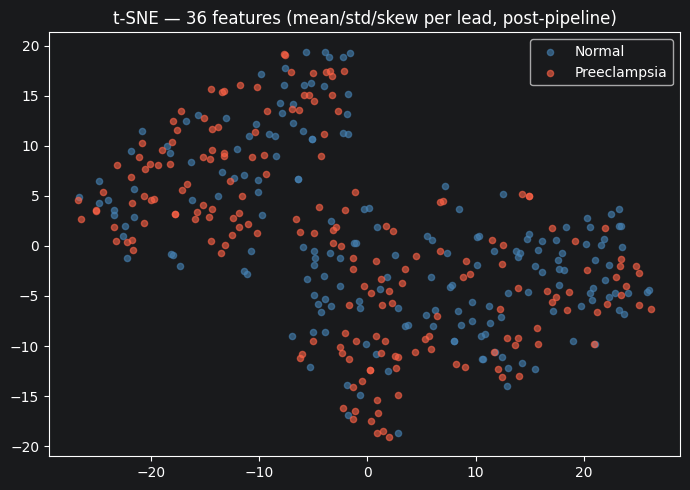

In [32]:
from scipy.stats import skew as scipy_skew

def extract_features(X_arr):
    mu = X_arr.mean(axis=2)                     # (N, 12)
    sd = X_arr.std(axis=2)                      # (N, 12)
    sk = scipy_skew(X_arr, axis=2)              # (N, 12) — NaN if lead is flat
    feats = np.concatenate([mu, sd, sk], axis=1)  # (N, 36)
    np.nan_to_num(feats, copy=False, nan=0.0)   # replace NaN with 0
    return feats

feats = extract_features(X_norm)
print(f"Features: {feats.shape}  NaNs: {np.isnan(feats).sum()}")

try:
    import umap
    embedding = umap.UMAP(n_components=2, random_state=42).fit_transform(feats)
    method = "UMAP"
except ImportError:
    from sklearn.manifold import TSNE
    print("umap-learn not installed — falling back to t-SNE")
    embedding = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(feats)
    method = "t-SNE"

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(embedding[y==0, 0], embedding[y==0, 1],
           s=20, alpha=0.6, color="steelblue", label="Normal")
ax.scatter(embedding[y==1, 0], embedding[y==1, 1],
           s=20, alpha=0.6, color="tomato", label="Preeclampsia")
ax.set_title(f"{method} — 36 features (mean/std/skew per lead, post-pipeline)")
ax.legend()
plt.tight_layout()
plt.show()

In [33]:
from sklearn.metrics import silhouette_score

# ── Metric 1: f_peak from PSD (Step 8) ────────────────────────────────────────
# Average PSD difference across all 12 leads, find the frequency with max divergence
psd_diff_all = []
for i in range(12):
    f_psd, psd_n = class_psd(X_neg, i)
    _,     psd_p = class_psd(X_pos, i)
    psd_diff_all.append(np.abs(psd_p - psd_n))
psd_diff_mean = np.stack(psd_diff_all).mean(axis=0)
mask_60 = f_psd <= 60
f_peak = f_psd[mask_60][np.argmax(psd_diff_mean[mask_60])]

if f_peak < 10:
    kernel_rec = "Large  (~50–100 samples)"
elif f_peak <= 40:
    kernel_rec = "Medium (~15–50 samples)"
else:
    kernel_rec = "Small  (~5–15 samples)"

# ── Metric 2: temporal peak width (Step 10) ───────────────────────────────────
half_max   = diff_smooth.max() / 2
above      = t[diff_smooth > half_max]
width_s    = float(above[-1] - above[0]) if len(above) > 1 else 0.0
transformer_rec = "Transformer / BiLSTM recommended" if width_s > 0.3 else "Local CNN features sufficient"

# ── Metric 3: CV of lead discriminability (Step 9) ────────────────────────────
cv_leads   = neg_log_p.std() / neg_log_p.mean() if neg_log_p.mean() > 0 else 0.0
attn_rec   = "Add lead-attention gate" if cv_leads > 0.5 else "Shared backbone across all 12 leads"

# ── Metric 4: Frobenius norm of correlation difference (Step 11) ──────────────
frob       = float(np.linalg.norm(corr_pos - corr_neg, 'fro'))
conv_rec   = "2D conv (cross-lead patterns present)" if frob > 2.0 else "1D conv per lead is sufficient"

# ── Metric 5: silhouette score on hand-crafted features (Step 13) ─────────────
sil        = silhouette_score(feats, y)
if sil > 0.4:
    depth_rec = "Shallow CNN (3–5 layers)"
elif sil > 0.1:
    depth_rec = "Medium depth (ResNet-style, ~10–18 layers)"
else:
    depth_rec = "Deep model with attention"

# ── Print results table ────────────────────────────────────────────────────────
rows = [
    ("EDA Step", "Metric",                    "Value",              "Architecture decision"),
    ("─"*9,      "─"*28,                      "─"*18,               "─"*38),
    ("Step 8",   "f_peak (PSD divergence)",   f"{f_peak:.1f} Hz",   f"Kernel size → {kernel_rec}"),
    ("Step 10",  "Temporal peak width",        f"{width_s:.3f} s",   transformer_rec),
    ("Step 9",   "CV of −log₁₀(p) leads",    f"{cv_leads:.3f}",    attn_rec),
    ("Step 11",  "Frobenius norm (corr diff)", f"{frob:.3f}",        conv_rec),
    ("Step 12b", "Mean kurtosis (per-lead)",    f"{mean_k:.2f}",       norm_rec),
    ("Step 13",  "Silhouette score (feats)",   f"{sil:.3f}",         depth_rec),
]

col_w = [10, 30, 20, 40]
for row in rows:
    print("  ".join(str(v).ljust(w) for v, w in zip(row, col_w)))

EDA Step    Metric                          Value                 Architecture decision                   
─────────   ────────────────────────────    ──────────────────    ──────────────────────────────────────  
Step 8      f_peak (PSD divergence)         1.0 Hz                Kernel size → Large  (~50–100 samples)  
Step 10     Temporal peak width             9.944 s               Transformer / BiLSTM recommended        
Step 9      CV of −log₁₀(p) leads           2.236                 Add lead-attention gate                 
Step 11     Frobenius norm (corr diff)      1.026                 1D conv per lead is sufficient          
Step 12b    Mean kurtosis (per-lead)        45.45                 Robust normalization (median/IQR) — heavy-tailed distributions
Step 13     Silhouette score (feats)        0.015                 Deep model with attention               
